# Reachy's cameras

In this notebook, you will learn how to get images from Reachy's cameras and how to use the controllable zooms.

Reachy 2021 has [two high quality cameras](https://www.kurokesu.com/shop/featured/CAMERA_C1_PRO) which deliver 720p at 30 fps. Each camera is equipped with a motorized zoom allowing to adapt the zoom level to the situation you're working in.

As in the other documentation notebooks, you need to connect to the robot first.

In [1]:
%matplotlib inline

# imports to display the images
from matplotlib import pyplot as plt
import cv2 as cv

# Reachy SDK import
from reachy_sdk import ReachySDK

In [2]:
# if you're not working directly on the robot, change 'localhost' to Reachy's IP address
reachy = ReachySDK('localhost')

Exception in thread Thread-4:
Traceback (most recent call last):
  File "/usr/lib/python3.8/threading.py", line 932, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.8/threading.py", line 870, in run
    self._target(*self._args, **self._kwargs)
  File "/home/marcelchollet/dev/reachy-sdk/reachy_sdk/reachy_sdk.py", line 227, in _start_sync_in_bg
    loop.run_until_complete(self._sync_loop())
  File "/usr/lib/python3.8/asyncio/base_events.py", line 616, in run_until_complete
    return future.result()
  File "/home/marcelchollet/dev/reachy-sdk/reachy_sdk/reachy_sdk.py", line 278, in _sync_loop
    await asyncio.gather(
  File "/home/marcelchollet/dev/reachy-sdk/reachy_sdk/reachy_sdk.py", line 237, in _get_stream_update_loop
    async for state_update in joint_stub.StreamJointsState(stream_req):
  File "/home/marcelchollet/.local/lib/python3.8/site-packages/grpc/aio/_call.py", line 321, in _fetch_stream_responses
    await self._raise_for_status()
  File "/home/marcelchollet/.l

Each camera can be accessed separately with *reachy.left_camera* and *reachy.right_camera*.

The left and right sides are considered from Reachy point of view.

<img src="https://raw.githubusercontent.com/pollen-robotics/reachy-sdk/notebook/notebooks/images/camera/reachy_head.jpeg" alt="drawing" width="300"/>

*.last_frame* from one of Reachy's cameras will return the last image that the camera captured.

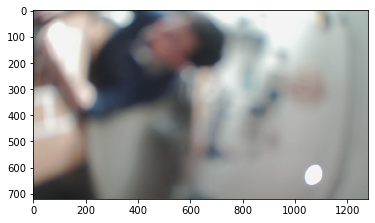

In [3]:
plt.figure()
plt.imshow(cv.cvtColor(reachy.left_camera.last_frame, cv.COLOR_BGR2RGB))

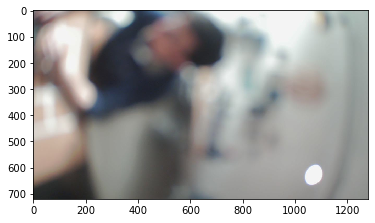

In [4]:
plt.figure()
plt.imshow(cv.cvtColor(reachy.left_camera.last_frame, cv.COLOR_BGR2RGB))

## Using the cameras zooms

### Zoom levels

The piloting of Reachy's zooms is working with a [python library](https://github.com/pollen-robotics/zoom_kurokesu) that we made. 

There are three zoom levels available: *'in'*, *'out'*, *'inter'*.

* *'in'*: for close objects,
* *'out'*: for further objects,
* *'inter'*: in between the 'in' and 'out' positions.

The zoom levels have been selected so that if you set the same zoom level on both cameras, you should see the same image (slightly shifted of course considering the cameras few cm from each other).

The current zoom level applied to Reachy's cameras can be checked.

In [5]:
reachy.left_camera.zoom_level

<ZoomLevel.INTER: 2>

In [6]:
reachy.right_camera.zoom_level

<ZoomLevel.INTER: 2>

The zoom level can be set with *ZoomLevel* from *reachy_sdk.camera*.

In [7]:
from reachy_sdk.camera import ZoomLevel

In [8]:
reachy.left_camera.zoom_level = ZoomLevel.OUT
reachy.right_camera.zoom_level = ZoomLevel.IN

You should hear the Reachy's zooms motors moving.

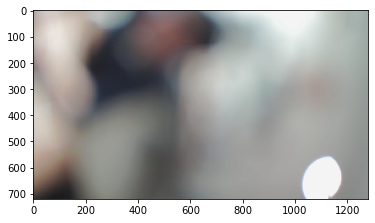

In [9]:
plt.figure()
plt.imshow(cv.cvtColor(reachy.left_camera.last_frame, cv.COLOR_BGR2RGB))

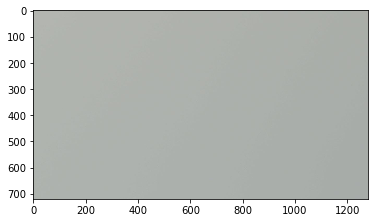

In [10]:
plt.figure()
plt.imshow(cv.cvtColor(reachy.right_camera.last_frame, cv.COLOR_BGR2RGB))

As you can see, the different zoom levels have been applied.

If when using the zooms you get images blurrier that what they are supposed to be, use the *homing* command.

Each zoom level sends positions instructions relatively to a base position and it can happen that the base positions get a bit drifted. The *homing* instruction bring the zoom motors to their limit and re set the base positions from it.

In [11]:
reachy.right_camera.zoom_homing()

True

### Zoom speed

The speed of the zoom motrs can also be changed along with the level.

The value of the speed is an int between 4000 and 40000, by default the value is at 10000 but you can chage it easily.

In [12]:
reachy.left_camera.zoom_speed = 35000

In [13]:
reachy.left_camera.zoom_speed

35000